### **Import the necessary libraries**

In [1]:
import nltk
import spacy 

import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

### **Load the dataset**

In [2]:
envi_data = pd.concat(
    [
        pd.read_csv("envi_dataset_part1.csv"),
        pd.read_csv("envi_dataset_part2.csv"),
        pd.read_csv("envi_dataset_part3.csv"),
    ]
)
envi_data.reset_index(drop=True, inplace=True)

In [3]:
envi_data.head()

,en,vi
0,"previously on "" the blacklist "" ...",trong phần trước của phim
1,- you want to call your daddy ?,- cháu muốn gọi cho bố hả ?
2,"- yeah , i want to tell him i 'm okay .","- vâng , cháu muốn nói với bố là cháu vẫn ổn ."
3,okay .,được rồi .
4,lizzy ...,lizzy ...


In [4]:
envi_data.tail()

,en,vi
2999996,"so , you are now one of us .",giờ nhóc nhập hội rồi .
2999997,your apprentice .,đệ tử ông đây .
2999998,lick .,liếm đi .
2999999,lick your finger .,liếm tay đi .
3000000,"now , gentlemen , before i go on the subject o...","thưa các vị , trước khi tôi đi vào vấn đề tự t..."


In [5]:
envi_data.shape

(3000001, 2)

In [6]:
envi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000001 entries, 0 to 3000000
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   en      object
 1   vi      object
dtypes: object(2)
memory usage: 45.8+ MB


We can see here, our dataset have 3,000,001 rows (sentences); and have 2 columns ('en' - English sentence, 'vi' - Vietnamese sentence)

### **Check for missing values**

In [7]:
envi_data.isnull().sum()

en    0
vi    0
dtype: int64

We can see here, our dataset have no missing values

### **Basic Statistics**

**Word Count**

In [ ]:
envi_data['en_words_count'] = envi_data['en'].apply(lambda x: len(x.split()))
envi_data['vi_words_count'] = envi_data['vi'].apply(lambda x: len(x.split()))

In [11]:
print(f"The number of English words count: {envi_data['en_words_count'].sum()} words")

The number of English words count: 25826569 words


In [12]:
print(f"The number of Vietnamese words count: {envi_data['vi_words_count'].sum()} words")

The number of Vietnamese words count: 28123869 words


In [13]:
envi_data.describe().map('{:,.2f}'.format)

,en_words_count,vi_words_count
count,"3,000,001.00","3,000,001.00"
mean,8.61,9.37
std,5.26,5.88
min,1.00,1.00
25%,5.00,6.00
50%,7.00,8.00
75%,11.00,12.00
max,124.00,171.00


In [14]:
def sentences_length(len_data):
    plt.figure(figsize=(15, 7), dpi=300)
    sns.set_style('darkgrid')
    sns.histplot(x=len_data, kde=True, binwidth=1) 
    plt.title('Sentences length histogram', fontsize=15, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.xlabel('Length', fontweight='bold')
    plt.ylabel('Frequency', fontweight='bold')
    plt.show()

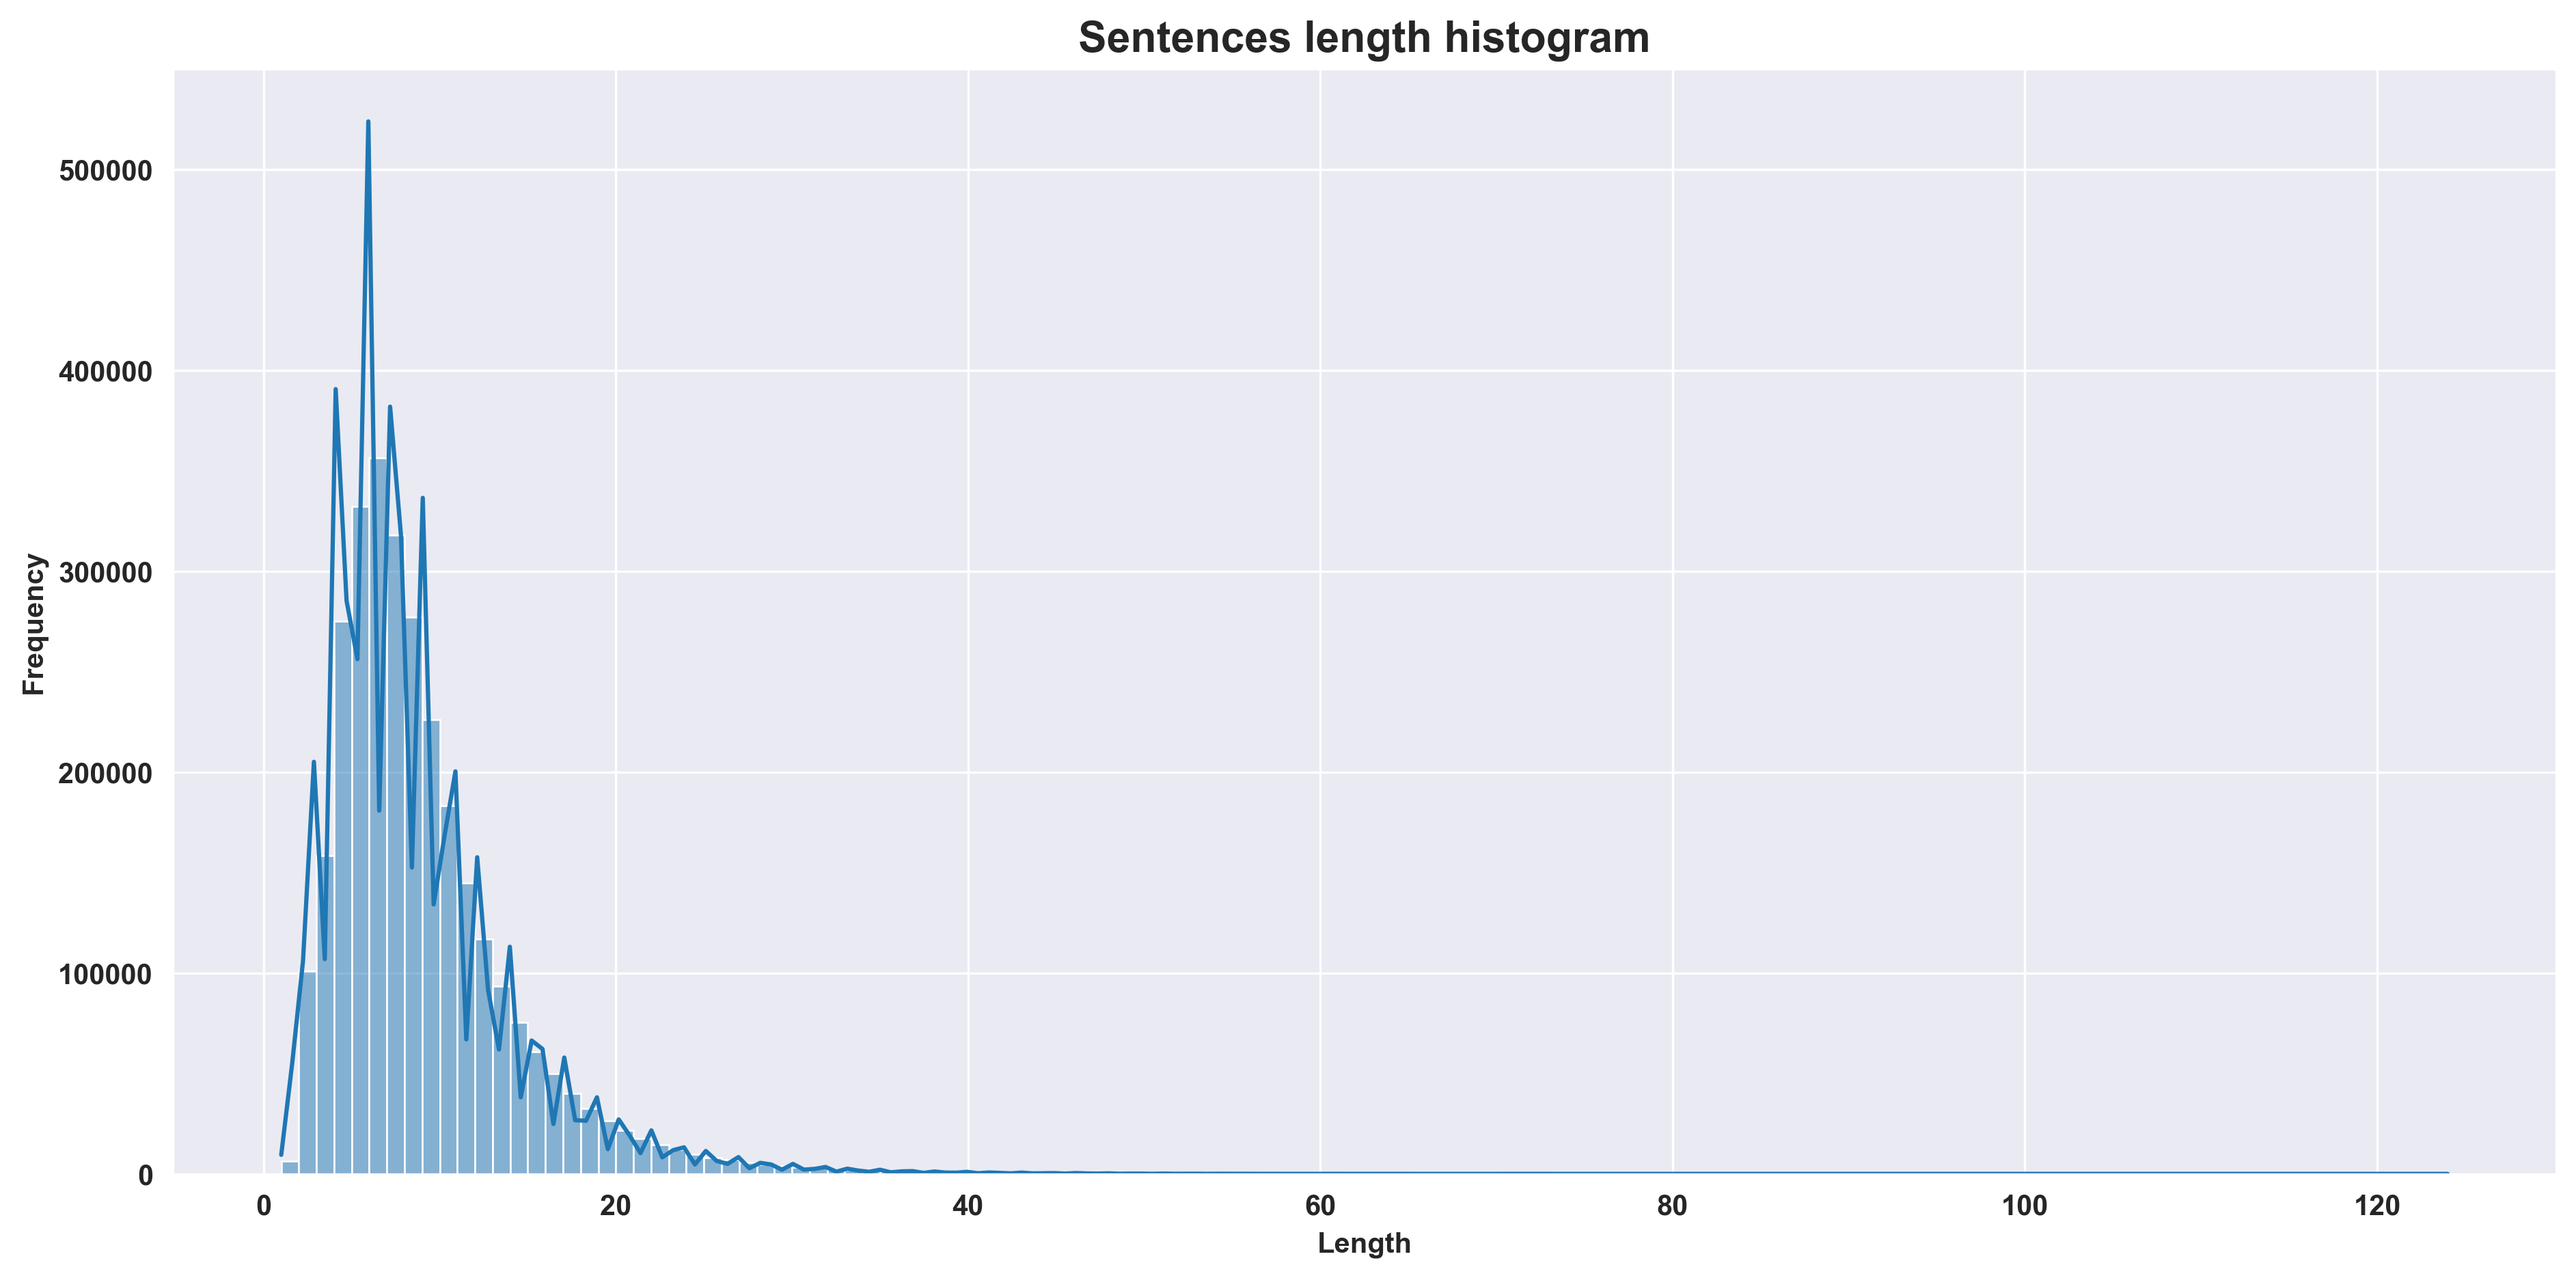

In [15]:
sentences_length(envi_data['en_words_count'])

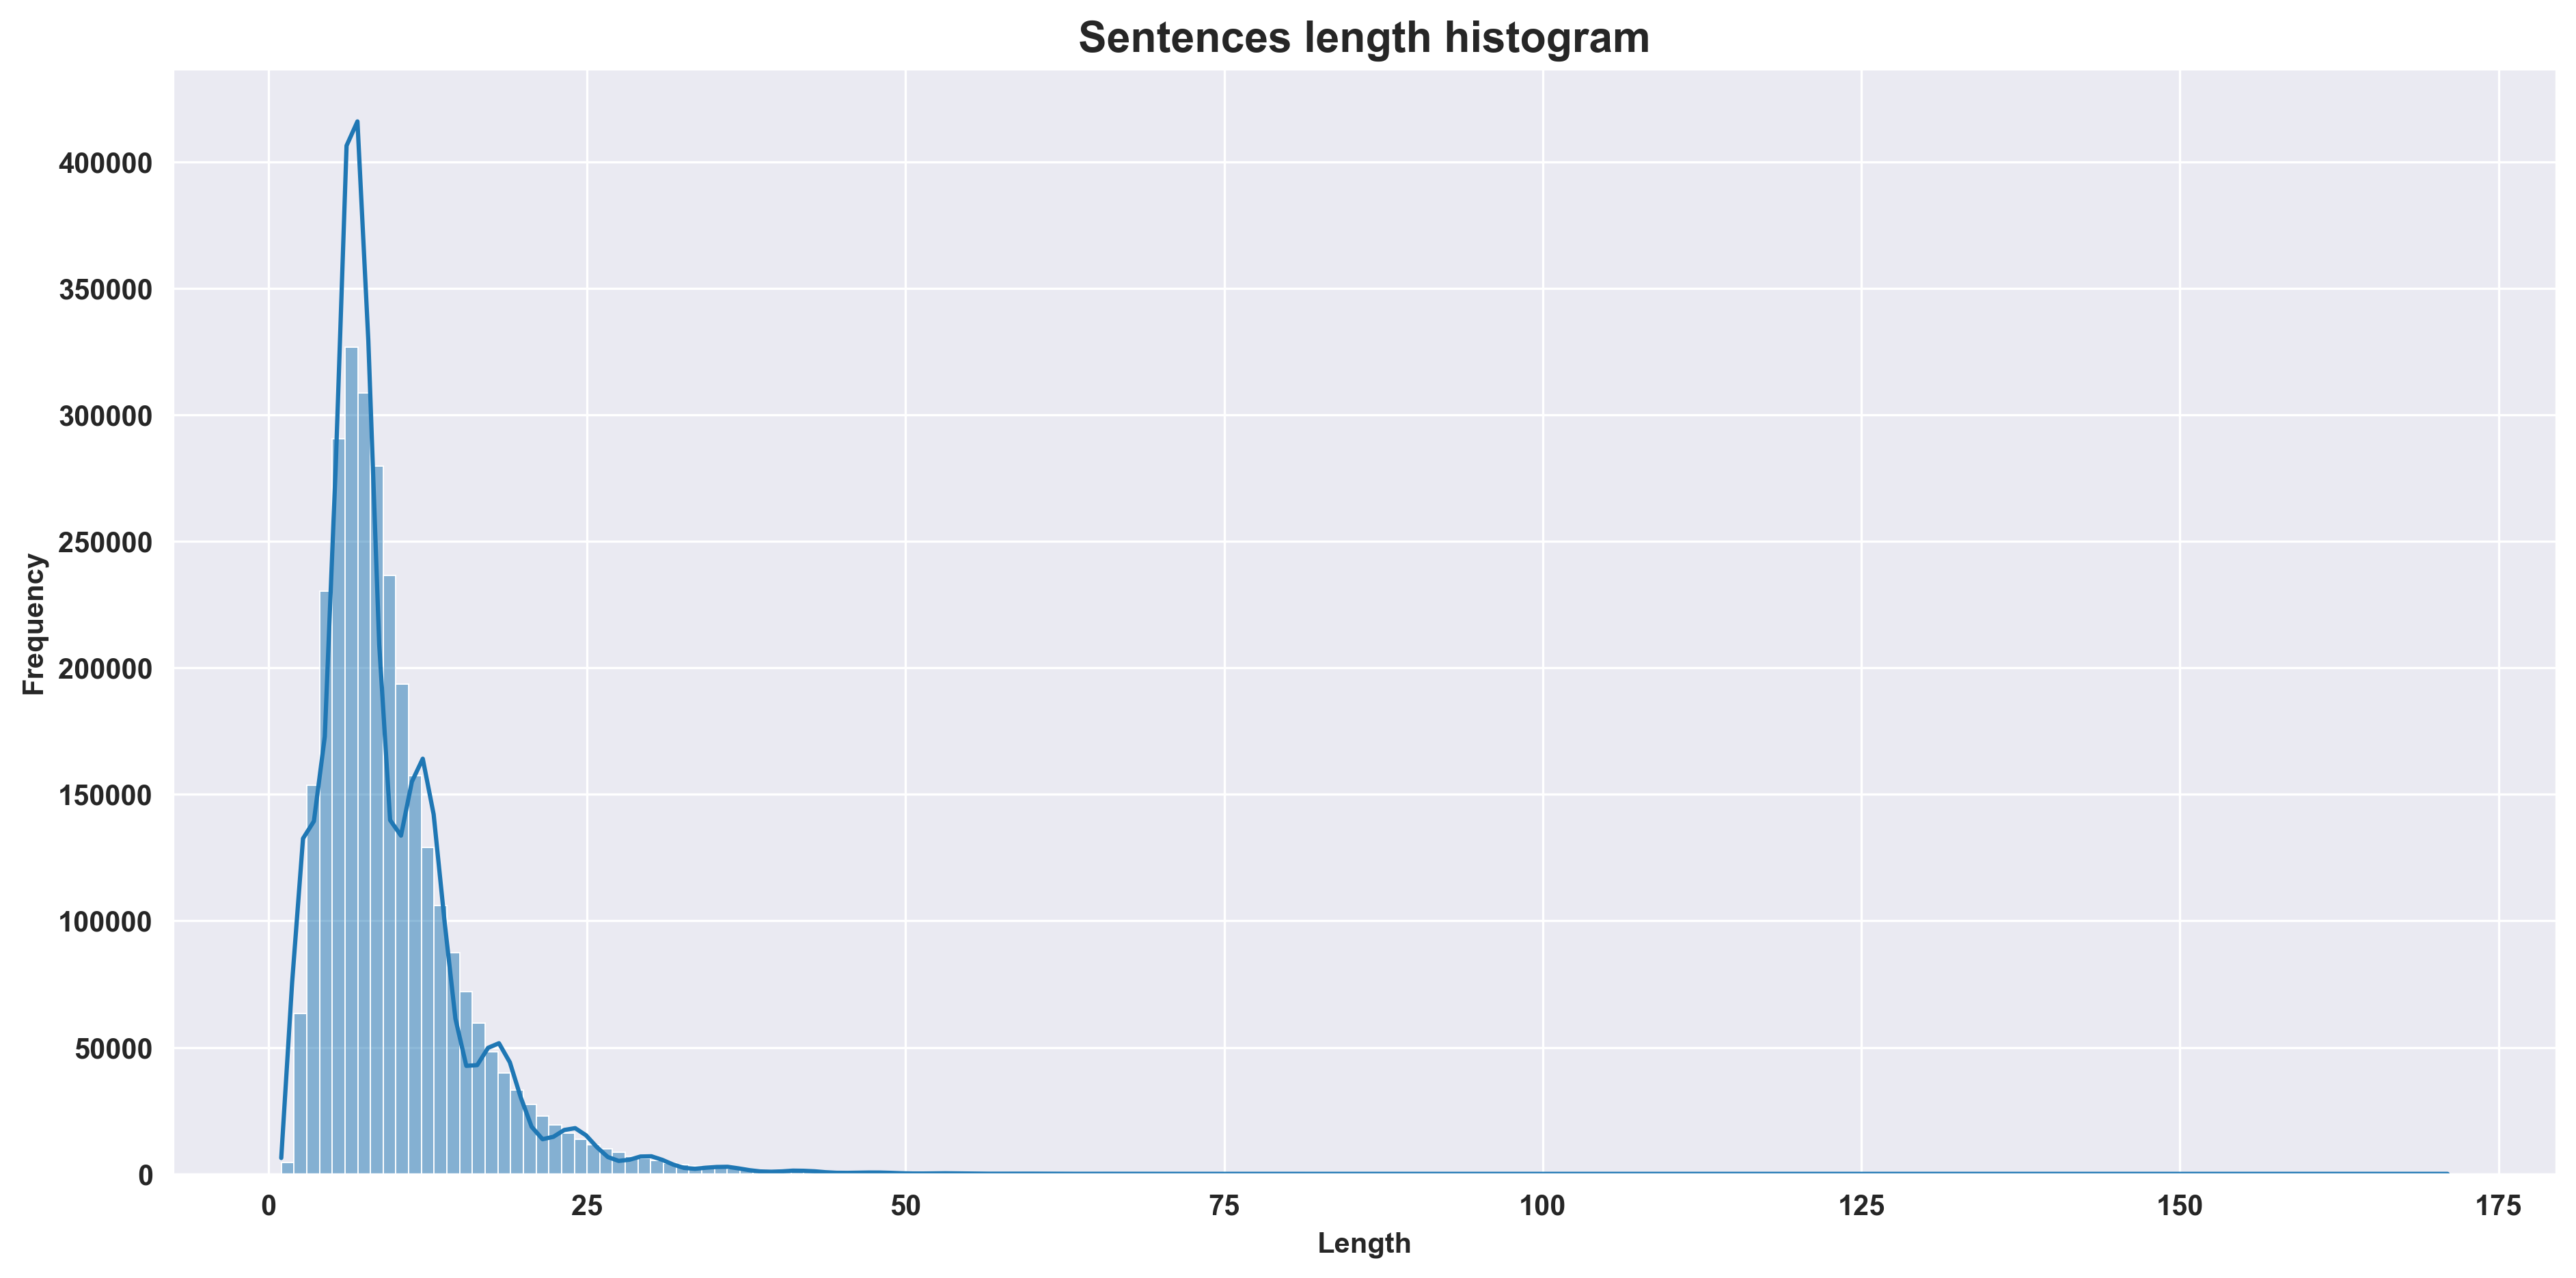

In [16]:
sentences_length(envi_data['vi_words_count'])

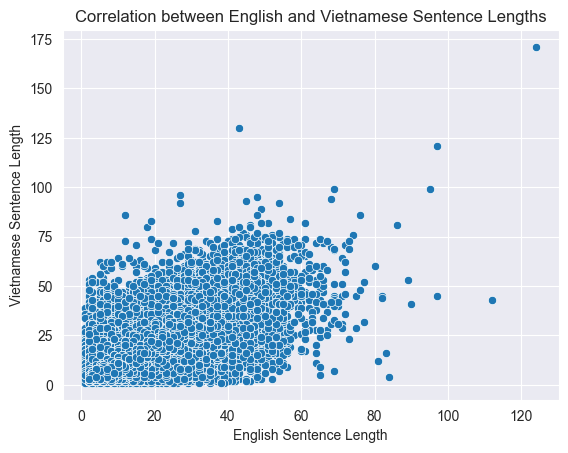

Correlation Matrix:
                 en_words_count  vi_words_count
en_words_count        1.000000        0.838942
vi_words_count        0.838942        1.000000


In [ ]:
sns.scatterplot(x=envi_data['en_words_count'], y=envi_data['vi_words_count'])
plt.xlabel("English Sentence Length")
plt.ylabel("Vietnamese Sentence Length")
plt.title("Correlation between English and Vietnamese Sentence Lengths")
plt.show()

correlation = envi_data[['en_words_count', 'vi_words_count']].corr()
print("Correlation Matrix:\n", correlation)

**Word Frequency**

In [ ]:
from collections import Counter

english_words = " ".join(envi_data["en"]).split()
vietnamese_words = " ".join(envi_data["vi"]).split()

english_counter = Counter(english_words)
vietnamese_counter = Counter(vietnamese_words)

In [19]:
# english_counter

In [20]:
# vietnamese_counter

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_top_words_bar_chart(word_freq):
    """
    Plots a bar chart for the top 10 words in the given frequency dictionary using seaborn for consistent colors.

    :param word_freq: Dictionary of word frequencies {word: frequency}
    """
    # Sort the dictionary by frequency and get the top 10 words (in descending order)
    sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:10]

    # Split the keys (words) and values (frequencies)
    words, frequencies = zip(*sorted_words)

    # Generate a color palette
    # colors = sns.color_palette("rocket", len(words))

    # Plot the bar chart
    plt.figure(figsize=(10, 8))
    plt.bar(words, frequencies, color='skyblue')
    plt.title("Top 10 Word Occurrences", fontsize=16)
    plt.xlabel("Words", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
    plt.show()

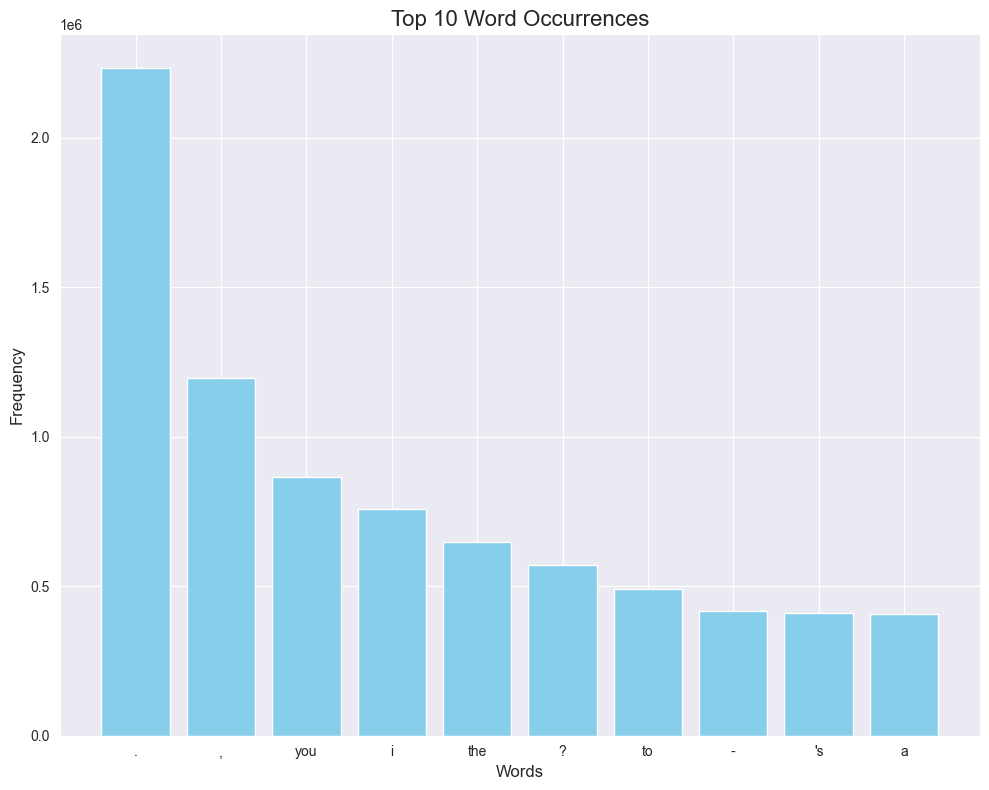

In [41]:
plot_top_words_bar_chart(english_counter)

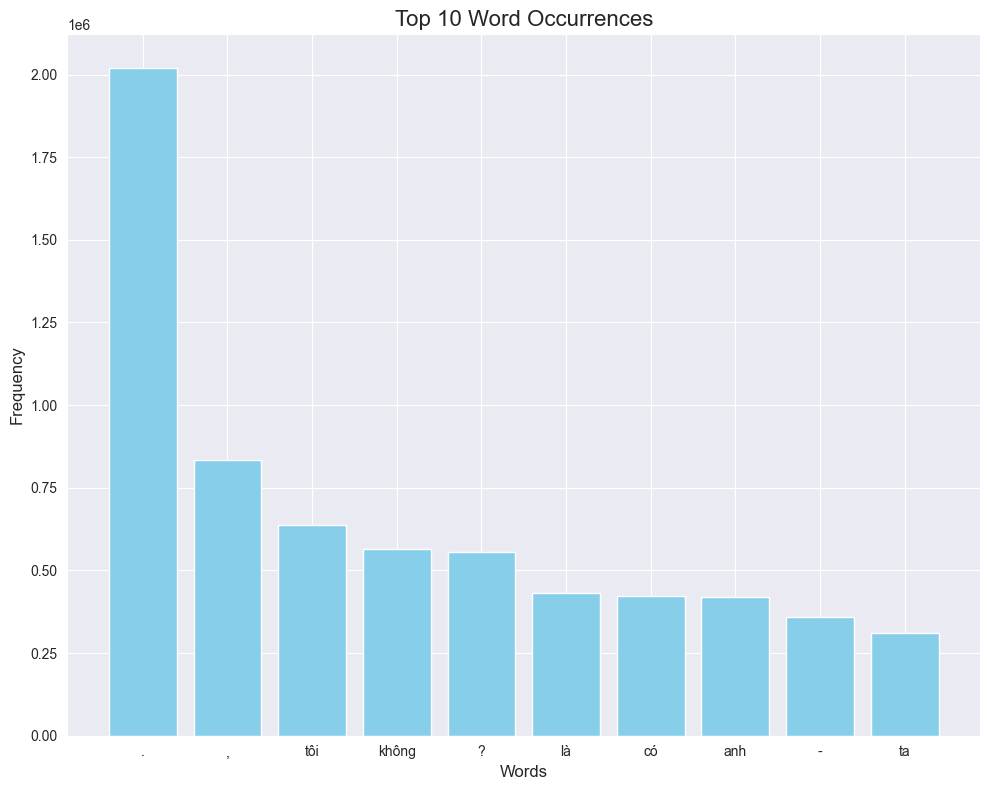

In [42]:
plot_top_words_bar_chart(vietnamese_counter)

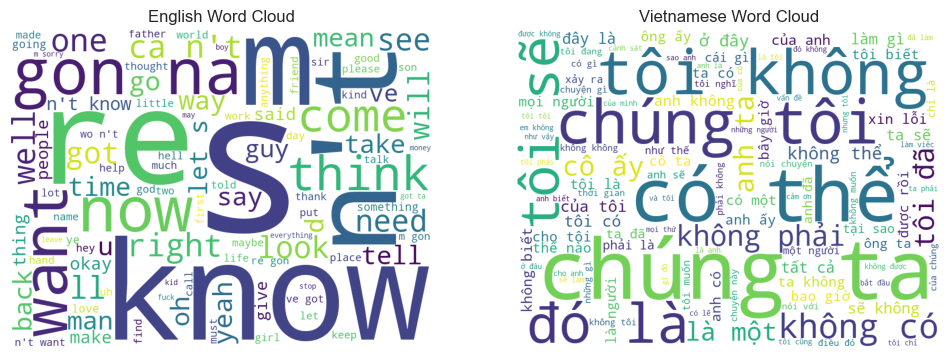

In [24]:
from wordcloud import WordCloud

en_text = " ".join(envi_data['en'])
vi_text = " ".join(envi_data['vi'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=800, height=600, background_color="white", max_words=100).generate(en_text))
plt.axis("off")
plt.title("English Word Cloud")

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=800, height=600, background_color="white", max_words=100).generate(vi_text))
plt.axis("off")
plt.title("Vietnamese Word Cloud")    

plt.show()

### **N-gram Analysis**

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

In [26]:
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

In [27]:
top_en_bigram = get_top_ngram(envi_data['en'], n=2)
top_en_trigram = get_top_ngram(envi_data['en'], n=3)

In [28]:
top_vi_bigram = get_top_ngram(envi_data['vi'], n=2)
top_vi_trigram = get_top_ngram(envi_data['vi'], n=3)

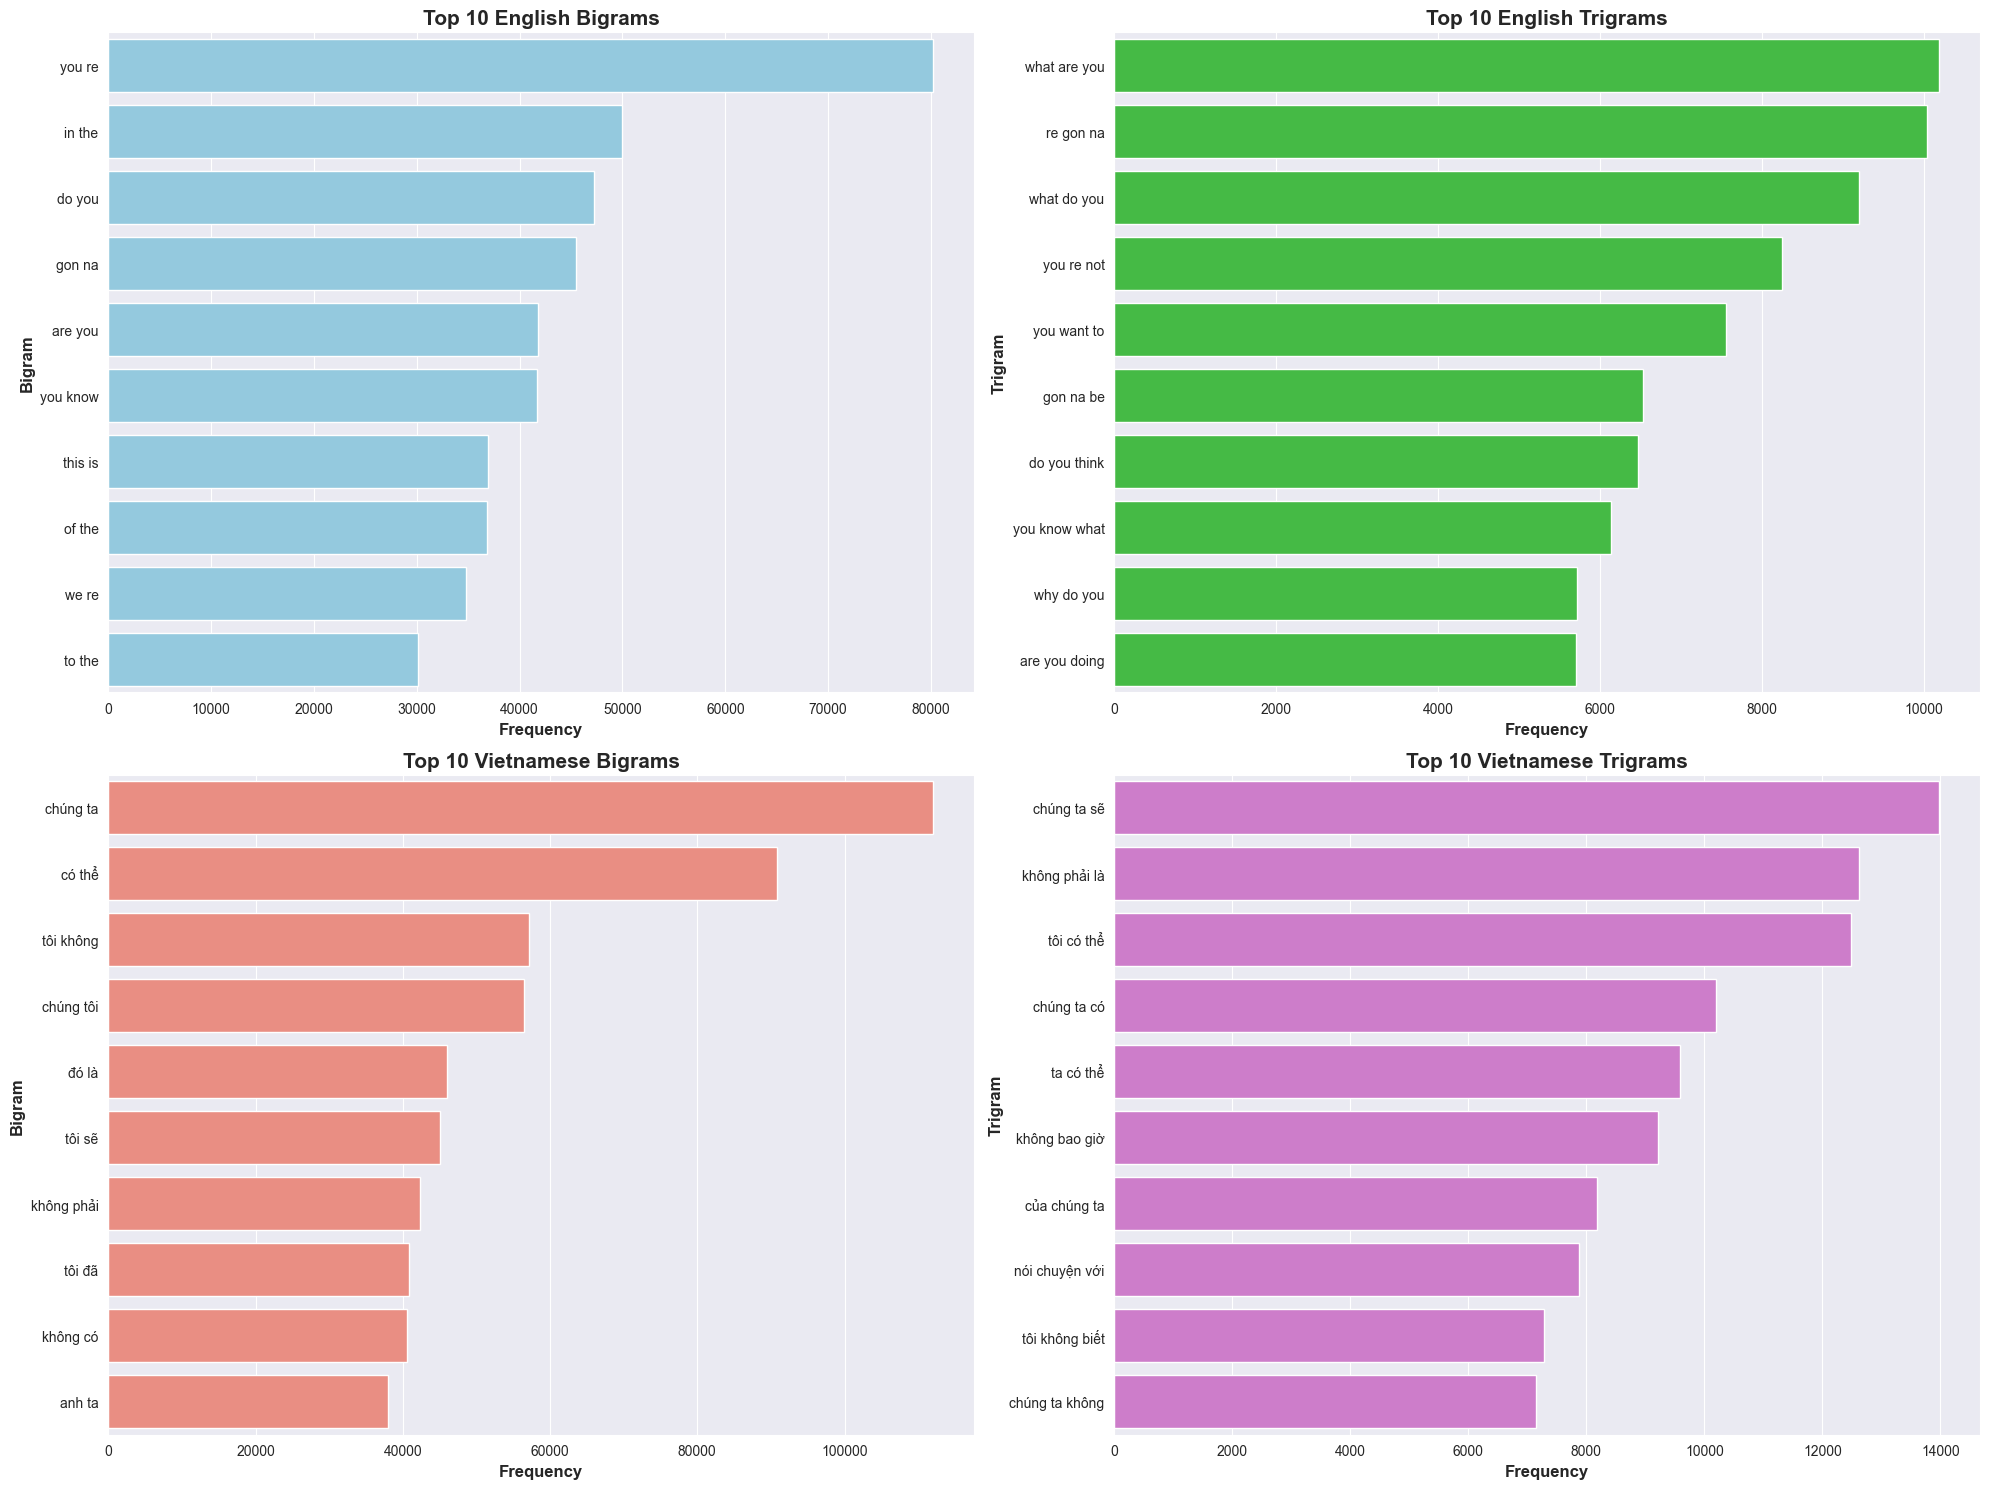

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

x, y = map(list, zip(*top_en_bigram))  # x: bigrams, y: frequencies
sns.barplot(x=y, y=x, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Bigram', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Top 10 English Bigrams', fontsize=15, fontweight='bold')

x, y = map(list, zip(*top_en_trigram))  # x: trigrams, y: frequencies
sns.barplot(x=y, y=x, color='limegreen', ax=axes[0, 1])
axes[0, 1].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Trigram', fontsize=12, fontweight='bold')  
axes[0, 1].set_title('Top 10 English Trigrams', fontsize=15, fontweight='bold')

x, y = map(list, zip(*top_vi_bigram))  # x: bigrams, y: frequencies
sns.barplot(x=y, y=x, color='salmon', ax=axes[1, 0])
axes[1, 0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Bigram', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Top 10 Vietnamese Bigrams', fontsize=15, fontweight='bold')

x, y = map(list, zip(*top_vi_trigram))  # x: trigrams, y: frequencies
sns.barplot(x=y, y=x, color='orchid', ax=axes[1, 1])
axes[1, 1].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Trigram', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Top 10 Vietnamese Trigrams', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()
